In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [27]:
data = pd.read_csv("Live.csv")
data.head(10)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
5,246675545449582_1645650162218773,photo,4/18/2018 2:14,217,6,0,211,5,1,0,0,0,NaN,NaN,NaN,NaN
6,246675545449582_1645564175560705,video,4/18/2018 0:24,503,614,72,418,70,10,2,0,3,NaN,NaN,NaN,NaN
7,246675545449582_1644824665634656,video,4/17/2018 7:42,295,453,53,260,32,1,1,0,1,NaN,NaN,NaN,NaN
8,246675545449582_1644655795651543,photo,4/17/2018 3:33,203,1,0,198,5,0,0,0,0,NaN,NaN,NaN,NaN
9,246675545449582_1638788379571618,photo,4/11/2018 4:53,170,9,1,167,3,0,0,0,0,NaN,NaN,NaN,NaN


## Things to do in the pre-processing of the data
- Numerical Encoding for status_type, status_plublished
- remove the column1,2,3,4 if all are NAN


In [28]:
print(data["Column1"].unique())
print(data["Column2"].unique())
print(data["Column3"].unique())
print(data["Column4"].unique())


# so we can drop these 4 columns
# drop() syntax :  df.drop(columns = 'A') or df.drop(columns=["A", "B", "C", "D"])

data.drop(columns = ["Column1", "Column2", "Column3", "Column4"], inplace = True)

[nan]
[nan]
[nan]
[nan]


In [88]:
data.head(10) # updated dataset with the removed columns


,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,year,month,day,hour
0,3,529,512,262,432,92,3,1,1,0,2018,4,22,6
1,1,150,0,0,150,0,0,0,0,0,2018,4,21,22
2,3,227,236,57,204,21,1,1,0,0,2018,4,21,6
3,1,111,0,0,111,0,0,0,0,0,2018,4,21,2
4,1,213,0,0,204,9,0,0,0,0,2018,4,18,3
5,1,217,6,0,211,5,1,0,0,0,2018,4,18,2
6,3,503,614,72,418,70,10,2,0,3,2018,4,18,0
7,3,295,453,53,260,32,1,1,0,1,2018,4,17,7
8,1,203,1,0,198,5,0,0,0,0,2018,4,17,3
9,1,170,9,1,167,3,0,0,0,0,2018,4,11,4


## Understanding the Data
We inspect shape, missing values, duplicates, and which columns are useful before encoding.

In [34]:
print(data["status_type"].unique()) # can be encoded to 0,1,2,3
print(data["status_published"].nunique())
print(data["status_id"].nunique())
print(len(data))

['video' 'photo' 'link' 'status']
6913
6997
7050


In [37]:
print("Shape of the data : ",data.shape)
print("Columns Types  : \n ", data.dtypes)


Shape of the data :  (7050, 12)
Columns Types  : 
  status_id           object
status_type         object
status_published    object
num_reactions        int64
num_comments         int64
num_shares           int64
num_likes            int64
num_loves            int64
num_wows             int64
num_hahas            int64
num_sads             int64
num_angrys           int64
dtype: object


In [ ]:
print("Checkout the null values in each columns : \n ", data.isnull().sum())
print("\n\n*** Duplicate Values ***  : \n ", data.duplicated().sum())

# We have a big data, removing 51 rows won't affect our resulting outcomes 


Checkout the null values in each columns : 
  status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64


*** Duplicate Values ***  : 
  51


### Pre-Processing
- Status_id can be dropped : as it's a label for post not a behaviour of the post
- K mean groups only cares about how the post behave, id is invaluable
- Other problem is two post can have similar engagement and still have totally different IDs. cause of ID, the Clusturing might put them in the different clustures, in reality they need to be in the same cluster
- They are in Object form not a number, Encoding of this feature provide no value



- ** we can drop 51 duplicate rows
- ** Encode the status type to numbers
- ** Convert the status published into numeric data parts (year, month, day, hour)
- ** Finally Standardize every feature 

In [ ]:
# drop status_id
data.drop(columns="status_id", inplace = True)

In [51]:
data

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7045,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [62]:
# remove the duplicate rows
print(data.isnull().sum())
print("\nNo of duplicate rows : \n", data.duplicated().sum())
print(data.drop_duplicates(inplace = True))


status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64

No of duplicate rows : 
 54
None


In [64]:
# we need to use reset_index as the drop_duplicates just remove the row data not it's label
data.reset_index(drop=True, inplace= True)
data.head()

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


- fit : learn from the data
- transform : applies what is learnt by fit
- fit_tranform does both on the same data

Tranform : X(scaled) = (X-mean)/std

In [66]:
# Encoding of Status Type 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data["status_type"] = encoder.fit_transform(data["status_type"])

print("Encoding map : \n", dict(zip(encoder.classes_,encoder.transform(encoder.classes_))))
data["status_type"].value_counts()


Encoding map : 
 {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}


status_type
1    4242
3    2332
2     359
0      63
Name: count, dtype: int64

In [67]:
data.head(10)

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,1,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,1,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,1,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
5,1,4/18/2018 2:14,217,6,0,211,5,1,0,0,0
6,3,4/18/2018 0:24,503,614,72,418,70,10,2,0,3
7,3,4/17/2018 7:42,295,453,53,260,32,1,1,0,1
8,1,4/17/2018 3:33,203,1,0,198,5,0,0,0,0
9,1,4/11/2018 4:53,170,9,1,167,3,0,0,0,0


In [ ]:
# Encoding status published
data["status_published"]= pd.to_datetime(data["status_published"])

In [73]:
data["status_published"].head()

0   2018-04-22 06:00:00
1   2018-04-21 22:45:00
2   2018-04-21 06:17:00
3   2018-04-21 02:29:00
4   2018-04-18 03:22:00
Name: status_published, dtype: datetime64[ns]

In [74]:
data['year'] = data['status_published'].dt.year
data['month'] = data['status_published'].dt.month
data['day'] = data["status_published"].dt.day
data["hour"] = data["status_published"].dt.hour

data.drop(columns = ["status_published"], inplace = True)
data.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,year,month,day,hour
0,3,529,512,262,432,92,3,1,1,0,2018,4,22,6
1,1,150,0,0,150,0,0,0,0,0,2018,4,21,22
2,3,227,236,57,204,21,1,1,0,0,2018,4,21,6
3,1,111,0,0,111,0,0,0,0,0,2018,4,21,2
4,1,213,0,0,204,9,0,0,0,0,2018,4,18,3


### Standardization

In [76]:
from sklearn.preprocessing import StandardScaler

processed_data = data.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("Scaled shape : ", X_scaled.shape)


Scaled shape :  (6996, 14)


In [84]:
X_scaled  # Numpy array, so pandas functions won't work
# it's mean should be zero 0 and S.D = 1
print("\n Mean of data : \n", np.round(X_scaled.mean(axis=0),3))
print("\n SD : \n", np.round(X_scaled.std(axis=0),3))


 Mean of data : 
 [ 0. -0.  0.  0. -0.  0.  0.  0.  0.  0. -0.  0. -0. -0.]

 SD : 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Data is now ready for K-Means: numeric, no IDs, no missing values, and all features on the same scale.

---

## K-Means end-to-end
Workflow:
1. Elbow method (WCSS) to shortlist k
2. Silhouette score to confirm k
3. Fit K-Means++ with that k
4. Visualize clusters (PCA → 2D)
5. Interpret clusters using original (unscaled) feature means

In [86]:
from sklearn.cluster import KMeans
wcss = []
K_range = range(1,11)

for k in K_range :
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
wcss

[97944.00000000003,
 82084.91124326471,
 72151.153726075,
 64936.38826670244,
 59749.91199350468,
 54566.78471399809,
 51058.067115855796,
 48330.370001336094,
 45440.35001270902,
 42037.83577932171]

In [11]:
from sklearn.cluster import KMeans

# WCSS / inertia = sum of squared distances from each point to its centroid
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss


[97944.00000000004,
 82084.91124326471,
 72151.15372607499,
 64936.38826670244,
 59749.91199350468,
 54566.78471399809,
 51058.067115855796,
 48330.370001336094,
 45440.35001270902,
 42037.83577932171]

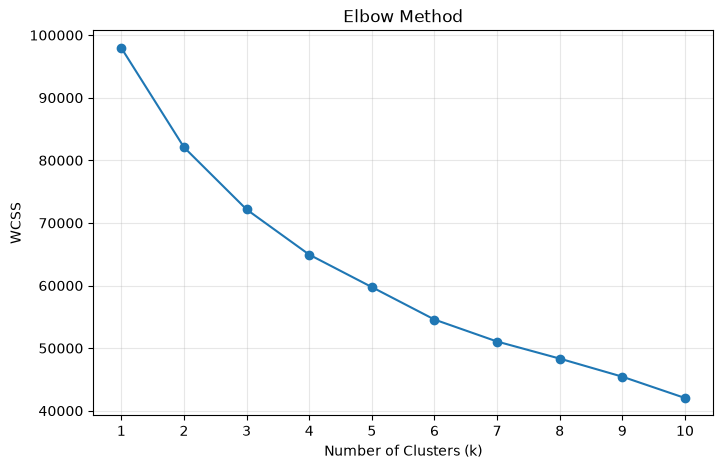

In [87]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o")
plt.xticks(K_range)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True, alpha=0.3)
plt.show()


### Silhouette score
The elbow can be a soft bend. Silhouette (range -1 to 1) measures how well-separated clusters are:
- closer to **1** → tight, well-separated clusters
- closer to **0** → overlapping
- negative → likely the wrong cluster

We skip k=1 because silhouette needs at least 2 clusters.

In [ ]:
from sklearn.

In [13]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}  |  silhouette = {score:.4f}")


k = 2  |  silhouette = 0.6076


k = 3  |  silhouette = 0.4345


k = 4  |  silhouette = 0.2138


k = 5  |  silhouette = 0.1705


k = 6  |  silhouette = 0.2161


k = 7  |  silhouette = 0.2321


k = 8  |  silhouette = 0.2321


k = 9  |  silhouette = 0.1930


k = 10  |  silhouette = 0.2032


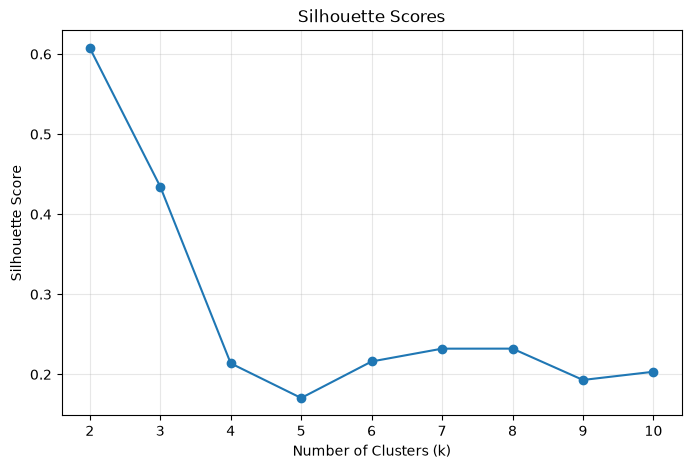

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.grid(True, alpha=0.3)
plt.show()


### Fit the final K-Means++ model
Use the k suggested by elbow + silhouette. For this Facebook Live dataset that is typically **k = 3 or 4**.
`init="k-means++"` picks later centroids far from existing ones, so we avoid a bad random start.

In [15]:
# k=4 is a common choice on this dataset (photo / video / status / link-like engagement groups).
# After you run the elbow + silhouette cells, you can change this if another k looks clearly better.
best_k = 4

kmeans = KMeans(n_clusters=best_k, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

processed_data["cluster"] = cluster_labels

print("Cluster sizes:")
print(processed_data["cluster"].value_counts().sort_index())
print("\nFinal WCSS (inertia):", kmeans.inertia_)
print("Final silhouette:", silhouette_score(X_scaled, cluster_labels))


Cluster sizes:
cluster
0    2127
1     199
2    4306
3     364
Name: count, dtype: int64

Final WCSS (inertia): 64936.38826670244


Final silhouette: 0.21376376947271064


### Visualize in 2D with PCA
We clustered in many dimensions. PCA compresses the scaled features into 2 axes so we can plot the clusters.
These 2 axes are not original columns — they are combinations that keep as much variance as possible.

Variance kept by PC1 + PC2: 0.396


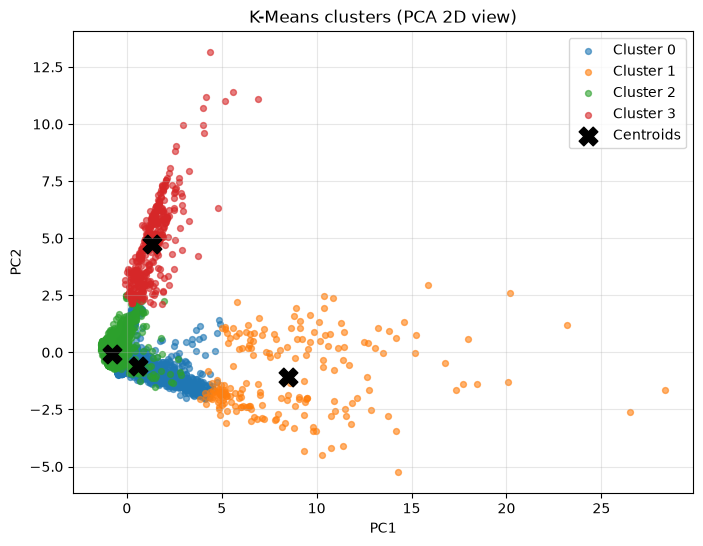

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance kept by PC1 + PC2:", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8, 6))
for cluster_id in range(best_k):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.6, label=f"Cluster {cluster_id}")

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=180, c="black", marker="X", label="Centroids")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means clusters (PCA 2D view)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpret clusters
Look at **unscaled** means so numbers stay in original units (likes, comments, etc.).
Also map `status_type` back to photo / video / status / link.

In [17]:
# Average engagement per cluster (original scale, easier to read than z-scores)
cluster_profile = processed_data.groupby("cluster").mean(numeric_only=True).round(2)
cluster_profile


,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,year,month,day,hour
cluster,,,,,,,,,,,,,,
0,2.97,168.70,374.07,73.50,143.66,23.06,0.66,0.89,0.27,0.15,2016.97,6.57,15.11,7.19
1,2.90,935.41,3589.89,572.58,724.13,172.01,22.56,11.84,3.04,1.84,2017.66,6.17,15.97,7.96
2,1.04,87.70,11.03,1.71,85.75,1.18,0.50,0.13,0.10,0.02,2016.11,6.69,16.12,8.08
3,1.59,1791.57,57.99,11.31,1787.06,2.37,1.96,0.16,0.02,0.01,2015.28,5.84,15.88,8.58


In [18]:
# How many of each post type landed in each cluster
type_names = {idx: name for idx, name in enumerate(encoder.classes_)}
processed_data["status_type_name"] = processed_data["status_type"].map(type_names)

pd.crosstab(processed_data["cluster"], processed_data["status_type_name"], margins=True)


status_type_name,link,photo,status,video,All
cluster,,,,,
0,0,3,57,2067,2127
1,0,10,0,189,199
2,49,4033,224,0,4306
3,14,196,78,76,364
All,63,4242,359,2332,6996


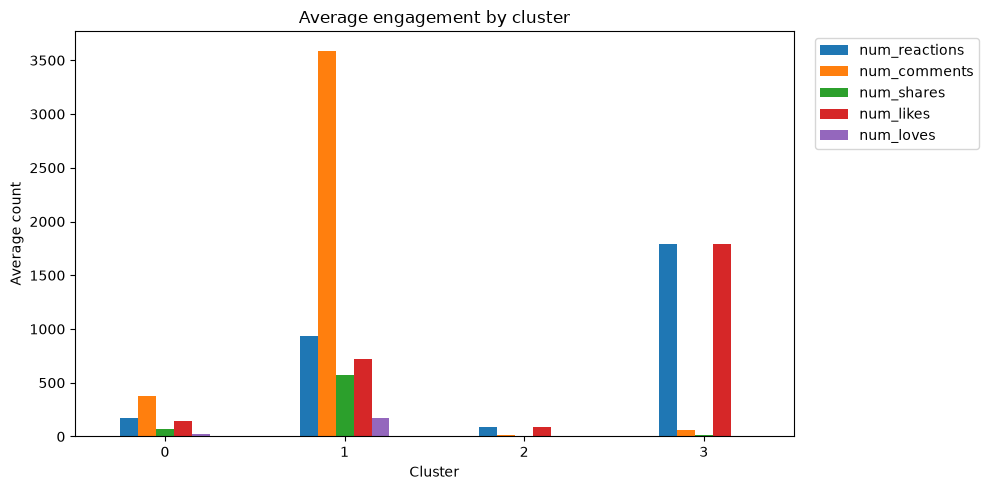

In [19]:
engagement_cols = ["num_reactions", "num_comments", "num_shares", "num_likes", "num_loves"]

cluster_profile[engagement_cols].plot(kind="bar", figsize=(10, 5))
plt.xlabel("Cluster")
plt.ylabel("Average count")
plt.title("Average engagement by cluster")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
